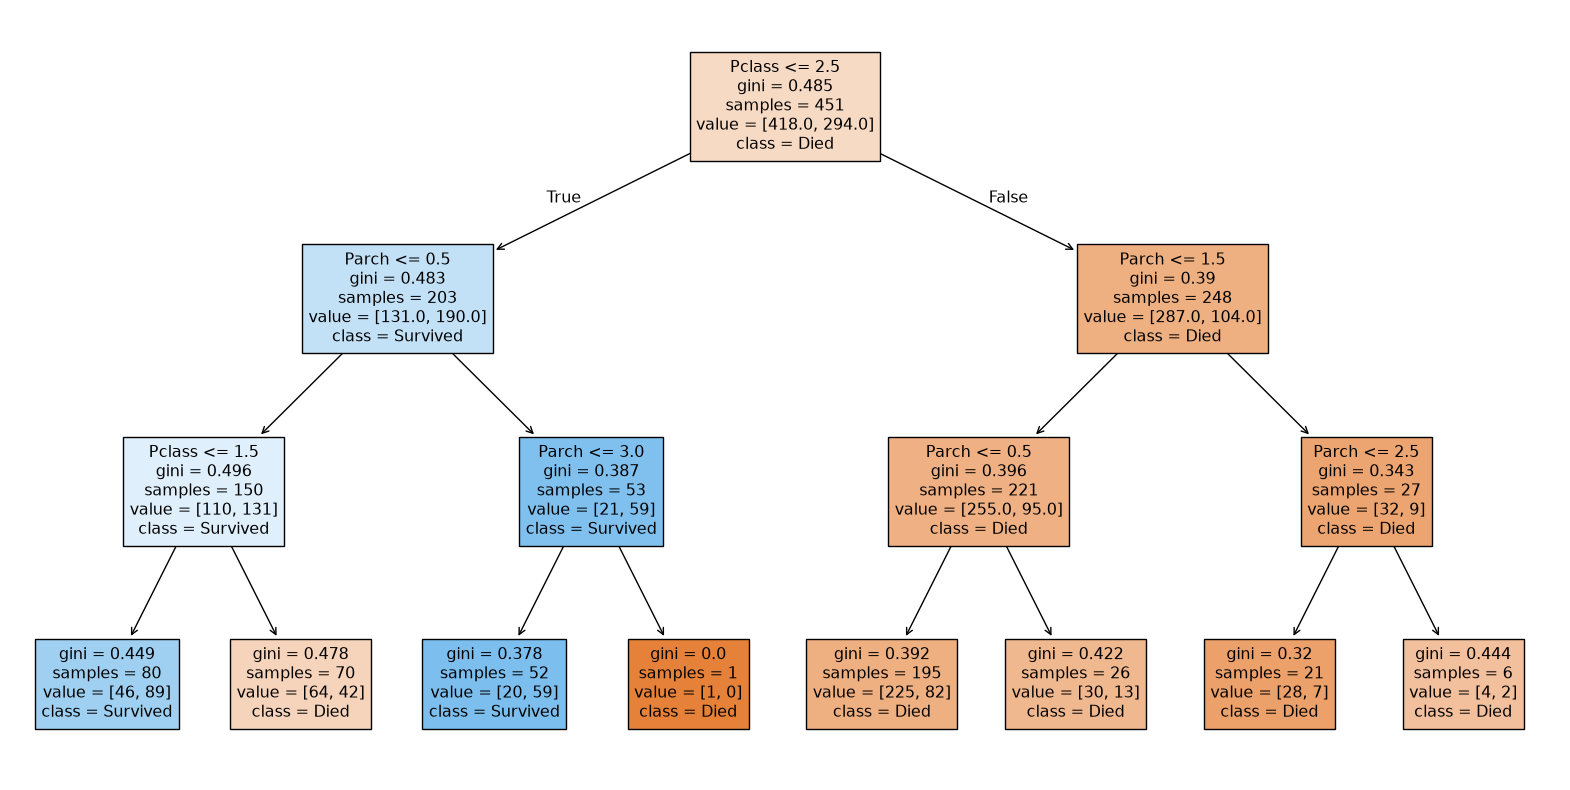

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


df=pd.read_csv('../data/titanic/train.csv',encoding='utf-8')

X=df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
y=df['Survived']

X['Sex']=X['Sex'].map({'male':0,'female':1})
X['Embarked']=X['Embarked'].map({'S':0,'C':1,'Q':2})

X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=0)

model=RandomForestClassifier(n_estimators=100,max_depth=3,random_state=0)
model.fit(X_train,y_train)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],feature_names=X.columns,class_names=['Died','Survived'],filled=True)
plt.show()

In [6]:
y_pred=model.predict(X_valid)

from sklearn.metrics import accuracy_score
accuracy_score( y_valid,y_pred)


0.8212290502793296

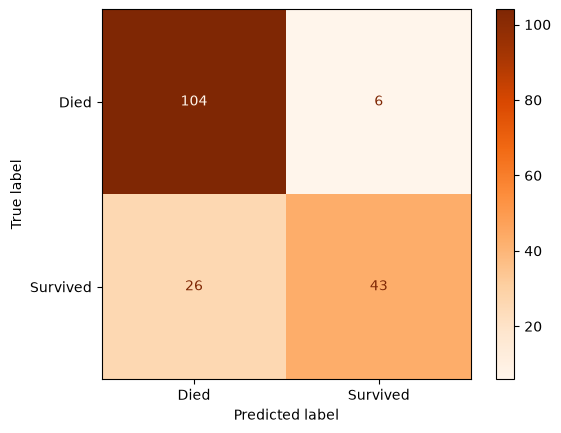

[[104   6]
 [ 26  43]]


In [7]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_valid,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Died','Survived'])
disp.plot(cmap='Oranges')
plt.show()
print(cm)

In [8]:
from sklearn.metrics import classification_report

y_pred=model.predict(X_valid)
print(classification_report(y_valid,y_pred,target_names=['Died','Survived']))


              precision    recall  f1-score   support

        Died       0.80      0.95      0.87       110
    Survived       0.88      0.62      0.73        69

    accuracy                           0.82       179
   macro avg       0.84      0.78      0.80       179
weighted avg       0.83      0.82      0.81       179



Sex         0.511710
Pclass      0.160689
Fare        0.130884
Age         0.087027
SibSp       0.056173
Embarked    0.027856
Parch       0.025661
dtype: float64


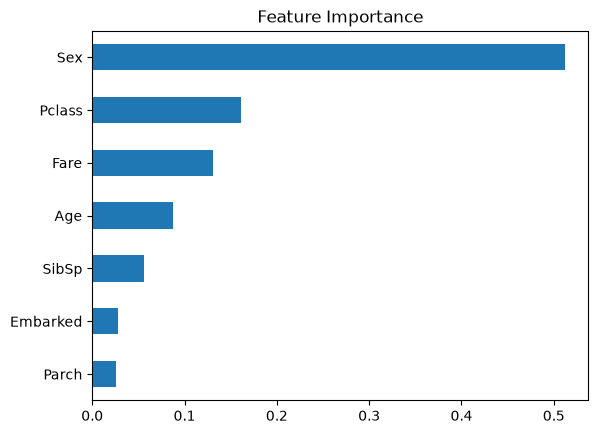

In [16]:
importance=pd.Series(model.feature_importances_,index=X.columns)
importance=importance.sort_values(ascending=False)

print(importance)

importance.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Feature Importance')
plt.show()

TypeError: 'str' object is not callable

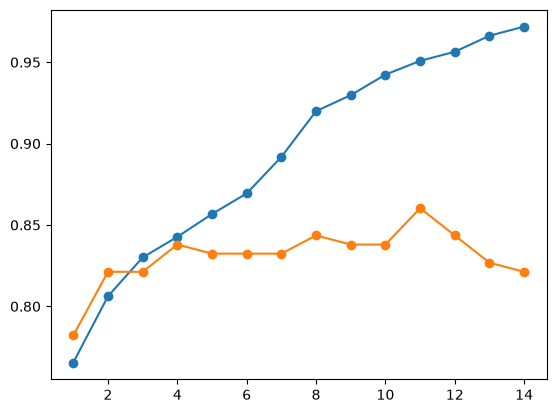

In [25]:
train_scores=[]
valid_scores=[]
depths=range(1,15)

for depth in depths:
    m=RandomForestClassifier(n_estimators=100,max_depth=depth,random_state=0)
    m.fit(X_train,y_train)
    train_scores.append(m.score(X_train,y_train))
    valid_scores.append(m.score(X_valid,y_valid))

plt.plot(depths,train_scores,marker='o',label='train')
plt.plot(depths,valid_scores,marker='o',label='valid')
plt.xlabel('max_depth')
plt.ylabel('accuracy')

plt.legend()
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV

parm_grid={'max_depth':range(1,15)}
grid=GridSearchCV(RandomForestClassifier(random_state=0),parm_grid,cv=5)
grid.fit(X_train,y_train)

print('best max_depth:', grid.best_params_)
print('best cv score:', grid.best_score_)
print('valid score with best model:', grid.best_estimator_.score(X_valid, y_valid))

best max_depth: {'max_depth': 8}
best cv score: 0.83006993006993
valid score with best model: 0.8435754189944135


## Random Forestの学習メモ(この回でつまずいた点・腹落ちした点)

### classification_reportの数字の見方
- accuracyだけだと少数派クラスの弱さが隠れる。macro avg(人数を無視した単純平均)なら少数派クラスの不出来を見逃さない
- weighted avgの**recall列は数式上、必ずaccuracyと完全一致する**(support加重平均の分子・分母がそのままaccuracyの定義に一致するため)。precision/f1のweighted avgだけはズレることがあり、それは「クラスによって間違え方(false positiveの出方)に偏りがある」時に起きる
- 実務の優先順位: ①accuracyで全体像 → ②macro avgで少数派の隠れた弱点を確認 → ③weighted avgはaccuracyと似た値になりがちなのでおまけ程度

### target_names / classes_の並び順問題
- `target_names`はy_true/y_predの**値をソートした順**に対応する(登場順でも人間が決めた順でもない)
- 確実な確認方法: `model.classes_`(fit後に確定、必ずソート済み)。`.unique()`は登場順なので信頼できない
- 「0,1」になるとは限らない。ラベルが-1/1、文字列(アルファベット順)、3クラス以上ということもあるので、思い込みで書かず必ず確認する

### 属性名末尾の`_`
- **fitした後にしか存在しない属性**には末尾に`_`が付く規則(`classes_`, `feature_importances_`, `feature_names_in_`など)。fit前から自分で決めた設定値(`n_estimators`, `max_depth`)には付かない

### feature_importances_の仕組み
- **predictとは無関係**。`fit()`の中で木を組み立てる過程で、各分岐がどれだけ不純度(gini)を減らしたかを特徴量ごとに集計した副産物。fit直後、predictを1回も呼んでいなくても取得できる
- 中身はラベルなしのnumpy配列で、並び順は「Xを書いた時の列順」のまま。**重要度の大小とは無関係**
- `pd.Series(model.feature_importances_, index=X.columns)`は名前を貼るだけで並べ替えはしない。`sort_values(ascending=False)`で初めて大きい順になる
- モデル内部は列名を覚えていない(数値配列として処理する)ので、fitに使った列順を人間側がもう一度指定し直す必要がある。sklearn1.0以降は`model.feature_names_in_`でモデル自身が記録した列名を直接取得できる

### depth別train/validスコアのループ
- for文の中では毎回`max_depth`を変えて**新しい木をゼロから作り直している**だけで、木を積み上げているわけではない
- `m.score(X, y)`は「predict → 正解と比較 → accuracy計算」を1行にまとめたショートカット
- ⚠️ `plt.xlabel=('max_depth')`のように`=`で書くと関数を文字列で上書きしてしまう。修正後もカーネル再起動しないと直らない

### GridSearchCVと交差検証(cv=5)
- `GridSearchCV(...)`の行はまだ何も実行しない。「試したい設定の注文書」を組み立てるだけで、実行は`grid.fit()`の瞬間
- 5分割交差検証: `X_train`を5ブロックに分け、「4ブロック学習+1ブロックテスト」をテスト役を入れ替えながら5回行い、平均を取る。単発の`train_test_split`より「たまたまこの分割だった」という運のブレを減らせる
- Random Forest内部のブートストラップ(重複ありサンプリング)とは目的が別物。CVは「公平な評価」のため、ブートストラップは「木ごとに多様性を持たせる」ため
- `grid.best_score_` = 5分割CVの平均(`X_train`の中だけで完結、`X_valid`は無関係)。`grid.best_estimator_.score(X_valid, y_valid)` = 選ばれた設定で`X_train`全体を使い直学習したモデルを、初めて`X_valid`で検証した値
- 単発のdepthカーブグラフの山(例: depth=11)とGridSearchCVの答え(例: depth=8)がズレることがある → 単発グラフは1回きりの分割のノイズを含むので、5分割平均の方が信頼度が高い

### random_stateの正体
- 疑似乱数: 同じseedなら必ず同じ数列が生成される決定論的な仕組み。同じデータ・同じコード・同じ`random_state`なら誰がやっても同じ結果になる(ライブラリのバージョン差や並列処理でごく僅かにズレることはある)

### n_estimators
- Random Forest内の木の本数。増やすほど安定するが、どこかで頭打ちになり計算コストだけが伸びる。`max_depth`と同様にループやGridSearchCVで最適値を探索できる

### 決定木からの発展
- Decision Tree/Random Forestは「一番分かれやすい基準を貪欲に選び続けるだけ」で理論的な深みは薄い。強さの理由は個々の木ではなく**バギング(独立な弱い予測を平均してブレを打ち消す)という仕組み側**にある
- 次のBoosting(LightGBM/XGBoost)では、木の組み方に勾配降下法が入り、回帰系でやった理論(損失関数・勾配)と合流する。そこで初めて`early_stopping`(逐次的に木を追加し、検証スコアが伸びなくなったら打ち切る)という概念が意味を持つ。Random Forestの木は互いに独立(bagging)なので、この概念はそもそも成立しない